# AI in Cybersecurity (ICT4416) — Internal Assessment 4
## Network Intrusion Detection System (NIDS) using Machine Learning
**Dataset:** UNSW-NB15 (subset: 40k train / 10k test)  
**Task:** Binary Classification — Normal vs Attack

---
## 0. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, fbeta_score,
    confusion_matrix, precision_recall_curve, auc, classification_report
)
from sklearn.utils import resample

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('All libraries imported successfully.')
print(f'TensorFlow version: {tf.__version__}')

All libraries imported successfully.
TensorFlow version: 2.21.0


---
## 1. Load Data

In [2]:
# Load training and testing datasets
train_df = pd.read_csv('UNSW_NB15_train_40k.csv')
test_df  = pd.read_csv('UNSW_NB15_test_10k.csv')

print('Training set shape :', train_df.shape)
print('Testing  set shape :', test_df.shape)
print('\nColumns:', list(train_df.columns))

Training set shape : (40000, 16)
Testing  set shape : (10000, 16)

Columns: ['proto', 'state', 'service', 'dur', 'sbytes', 'dbytes', 'spkts', 'dpkts', 'sload', 'dload', 'sttl', 'dttl', 'smean', 'dmean', 'sinpkt', 'label']


---
## Task (i) — Exploratory Data Analysis (EDA)

In [3]:
# ── 1.1 Basic Structure ──────────────────────────────────────────────────────
print('=== DATA TYPES & FIRST 5 ROWS ===')
display(train_df.head())
print('\n=== INFO ===')
train_df.info()

=== DATA TYPES & FIRST 5 ROWS ===


,proto,state,service,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
0,pri-enc,INT,-,0.000009,200,0,2,0,8.888889e+07,0.000000e+00,254,0,100,0,0.009000,1
1,tcp,FIN,-,0.049860,3926,57474,66,68,6.204572e+05,9.086081e+06,31,29,59,845,0.761846,0
2,tcp,FIN,-,0.998910,608,646,10,10,4.388784e+03,4.661081e+03,254,252,61,65,110.990000,1
3,tcp,FIN,smtp,0.595864,37492,3172,52,38,4.936831e+05,4.147255e+04,31,29,721,83,11.676843,0
4,udp,INT,-,0.000009,104,0,2,0,4.622222e+07,0.000000e+00,254,0,52,0,0.009000,0



=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   proto    40000 non-null  object 
 1   state    40000 non-null  object 
 2   service  40000 non-null  object 
 3   dur      40000 non-null  float64
 4   sbytes   40000 non-null  int64  
 5   dbytes   40000 non-null  int64  
 6   spkts    40000 non-null  int64  
 7   dpkts    40000 non-null  int64  
 8   sload    40000 non-null  float64
 9   dload    40000 non-null  float64
 10  sttl     40000 non-null  int64  
 11  dttl     40000 non-null  int64  
 12  smean    40000 non-null  int64  
 13  dmean    40000 non-null  int64  
 14  sinpkt   40000 non-null  float64
 15  label    40000 non-null  int64  
dtypes: float64(4), int64(9), object(3)
memory usage: 4.9+ MB


In [4]:
# ── 1.2 Statistical Summary ──────────────────────────────────────────────────
print('=== NUMERICAL FEATURE STATISTICS ===')
display(train_df.describe())

=== NUMERICAL FEATURE STATISTICS ===


,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
count,40000.000000,4.000000e+04,4.000000e+04,40000.000000,40000.000000,4.000000e+04,4.000000e+04,40000.00000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,1.181550,6.409099e+03,2.471327e+04,26.478525,30.275575,4.572907e+07,1.471366e+06,121.09915,70.684150,140.207025,198.178100,2068.309464,0.300000
std,5.715719,1.252525e+05,1.708381e+05,106.980146,129.778977,1.750041e+08,3.451494e+06,108.93431,97.926862,198.910097,305.898615,10659.913291,0.458263
min,0.000000,4.600000e+01,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,28.000000,0.000000,0.000000,0.000000
25%,0.000010,1.460000e+02,0.000000e+00,2.000000,0.000000,1.244276e+04,0.000000e+00,31.00000,0.000000,57.000000,0.000000,0.009000,0.000000
50%,0.026797,8.100000e+02,3.200000e+02,10.000000,6.000000,5.179283e+05,1.507469e+04,31.00000,29.000000,73.000000,78.000000,1.165287,0.000000
75%,0.647432,2.558000e+03,3.380000e+03,22.000000,22.000000,4.667234e+06,6.872587e+05,254.00000,29.000000,117.000000,136.000000,55.519361,1.000000
max,59.999989,1.202983e+07,1.465555e+07,9094.000000,10974.000000,5.988000e+09,2.235302e+07,255.00000,254.000000,1504.000000,1458.000000,84371.496000,1.000000


In [5]:
# ── 1.3 Missing Values ───────────────────────────────────────────────────────
missing = train_df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')

Missing values per column:
No missing values found.


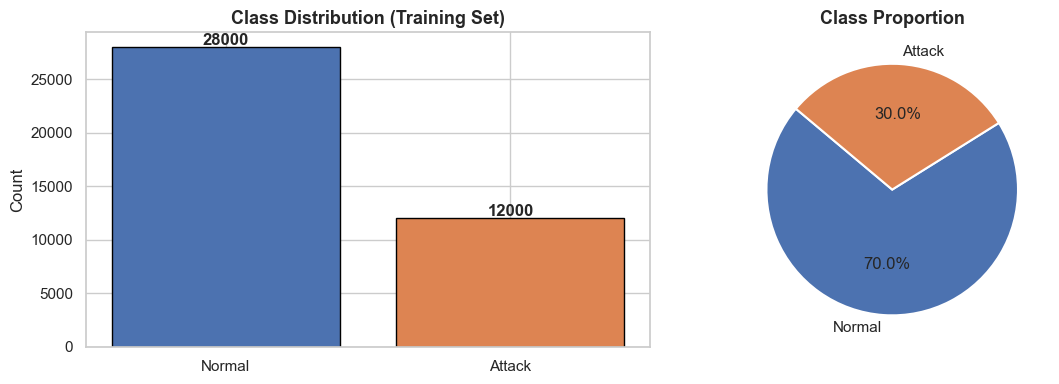

label
Normal    28000
Attack    12000
Name: count, dtype: int64

Imbalance ratio (majority:minority): 2.33:1


In [6]:
# ── 1.4 Class Distribution ───────────────────────────────────────────────────
label_map = {0: 'Normal', 1: 'Attack'}
class_counts = train_df['label'].map(label_map).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('Class Distribution (Training Set)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight')
plt.show()

print(class_counts)
ratio = class_counts.max() / class_counts.min()
print(f'\nImbalance ratio (majority:minority): {ratio:.2f}:1')

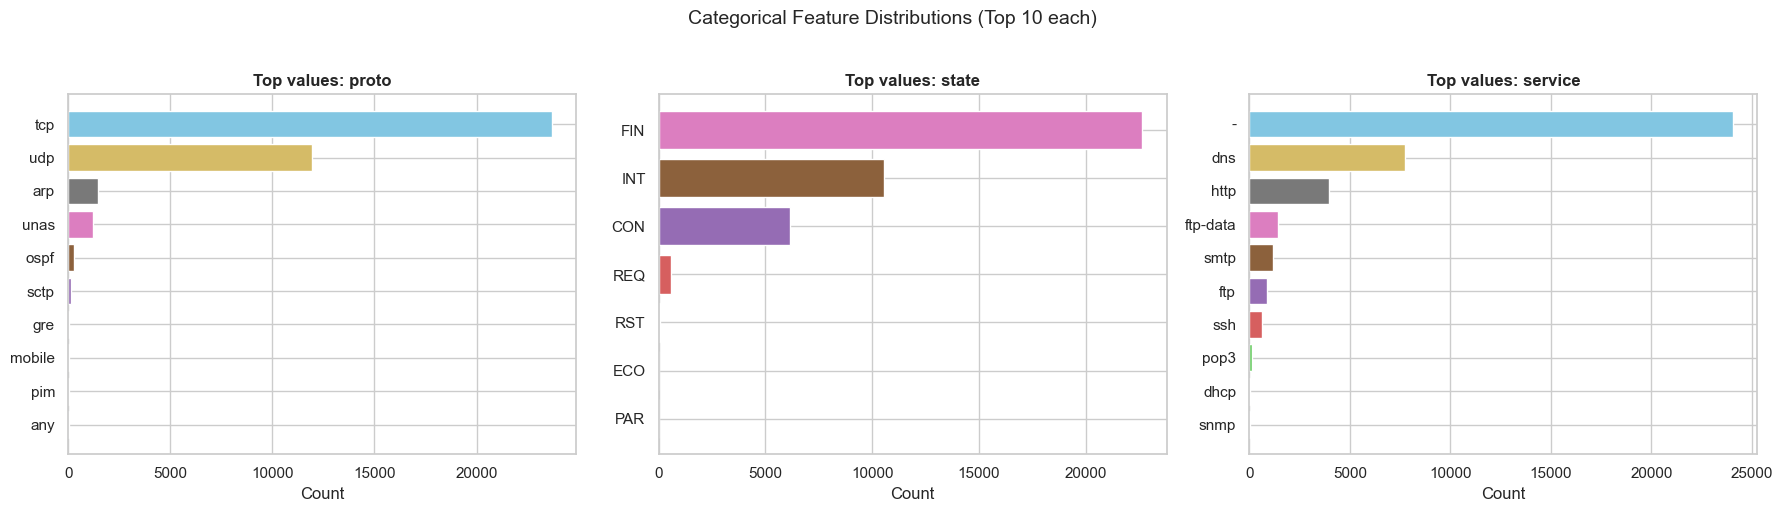

proto: 133 unique values — ['pri-enc', 'tcp', 'udp', 'unas', 'trunk-2', 'xns-idp', 'icmp', 'arp']
state: 7 unique values — ['INT', 'FIN', 'REQ', 'CON', 'ECO', 'RST', 'PAR']
service: 13 unique values — ['-', 'smtp', 'ftp-data', 'dns', 'http', 'ssh', 'ftp', 'pop3']


In [7]:
# ── 1.5 Categorical Feature Analysis ─────────────────────────────────────────
cat_cols = ['proto', 'state', 'service']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    top_vals = train_df[col].value_counts().head(10)
    ax.barh(top_vals.index[::-1], top_vals.values[::-1],
            color=sns.color_palette('muted', len(top_vals)))
    ax.set_title(f'Top values: {col}', fontweight='bold')
    ax.set_xlabel('Count')
plt.suptitle('Categorical Feature Distributions (Top 10 each)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_categorical_features.png', bbox_inches='tight')
plt.show()

for col in cat_cols:
    print(f'{col}: {train_df[col].nunique()} unique values — {list(train_df[col].unique()[:8])}')

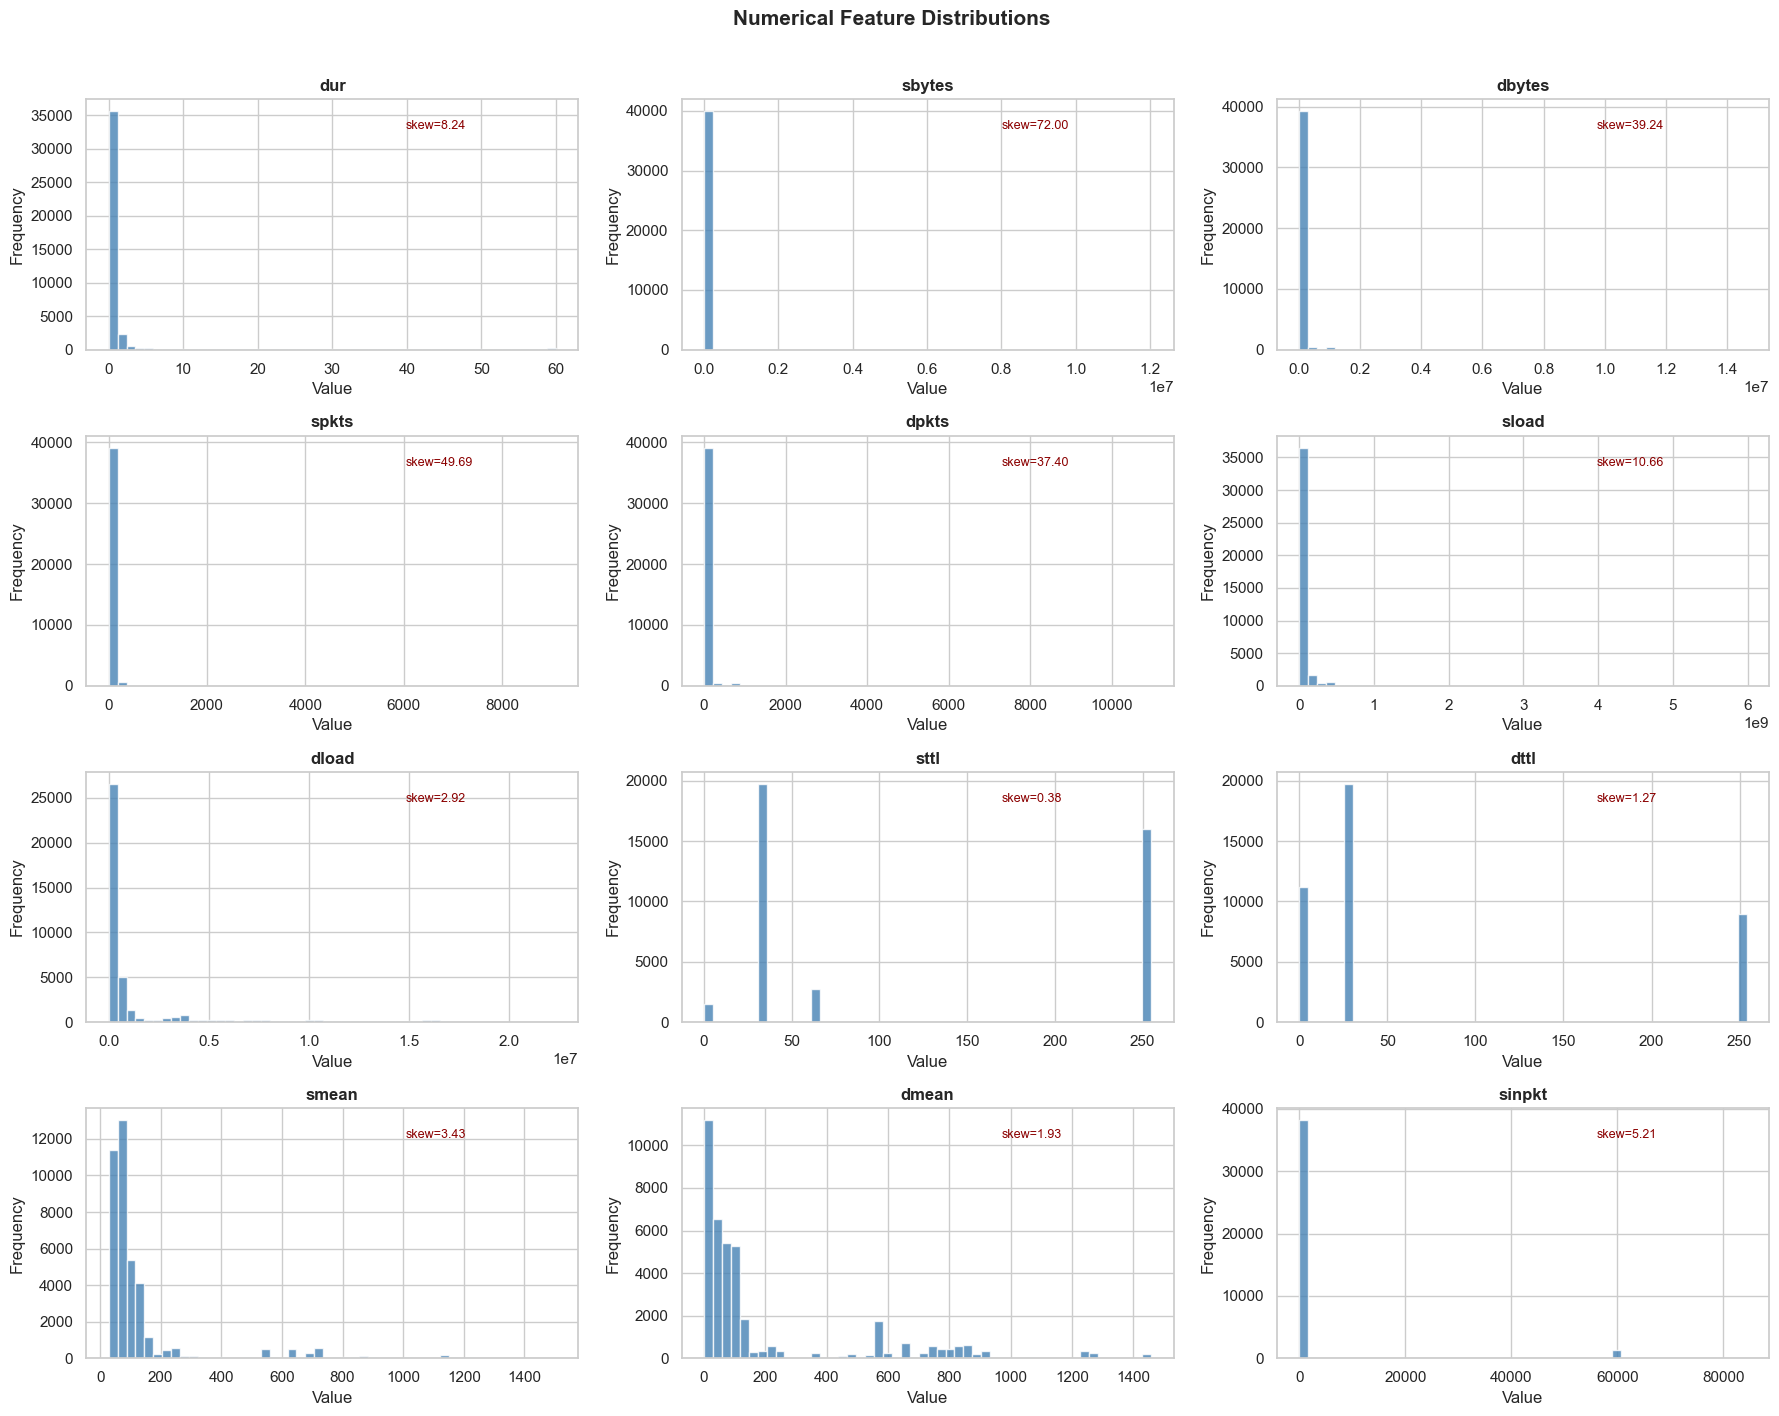

In [8]:
# ── 1.6 Numerical Feature Distributions ──────────────────────────────────────
num_cols = [c for c in train_df.columns if c not in cat_cols + ['label']]
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(train_df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    skew_val = train_df[col].skew()
    axes[i].annotate(f'skew={skew_val:.2f}', xy=(0.65, 0.88),
                     xycoords='axes fraction', fontsize=9,
                     color='darkred')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=15, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_num_distributions.png', bbox_inches='tight')
plt.show()

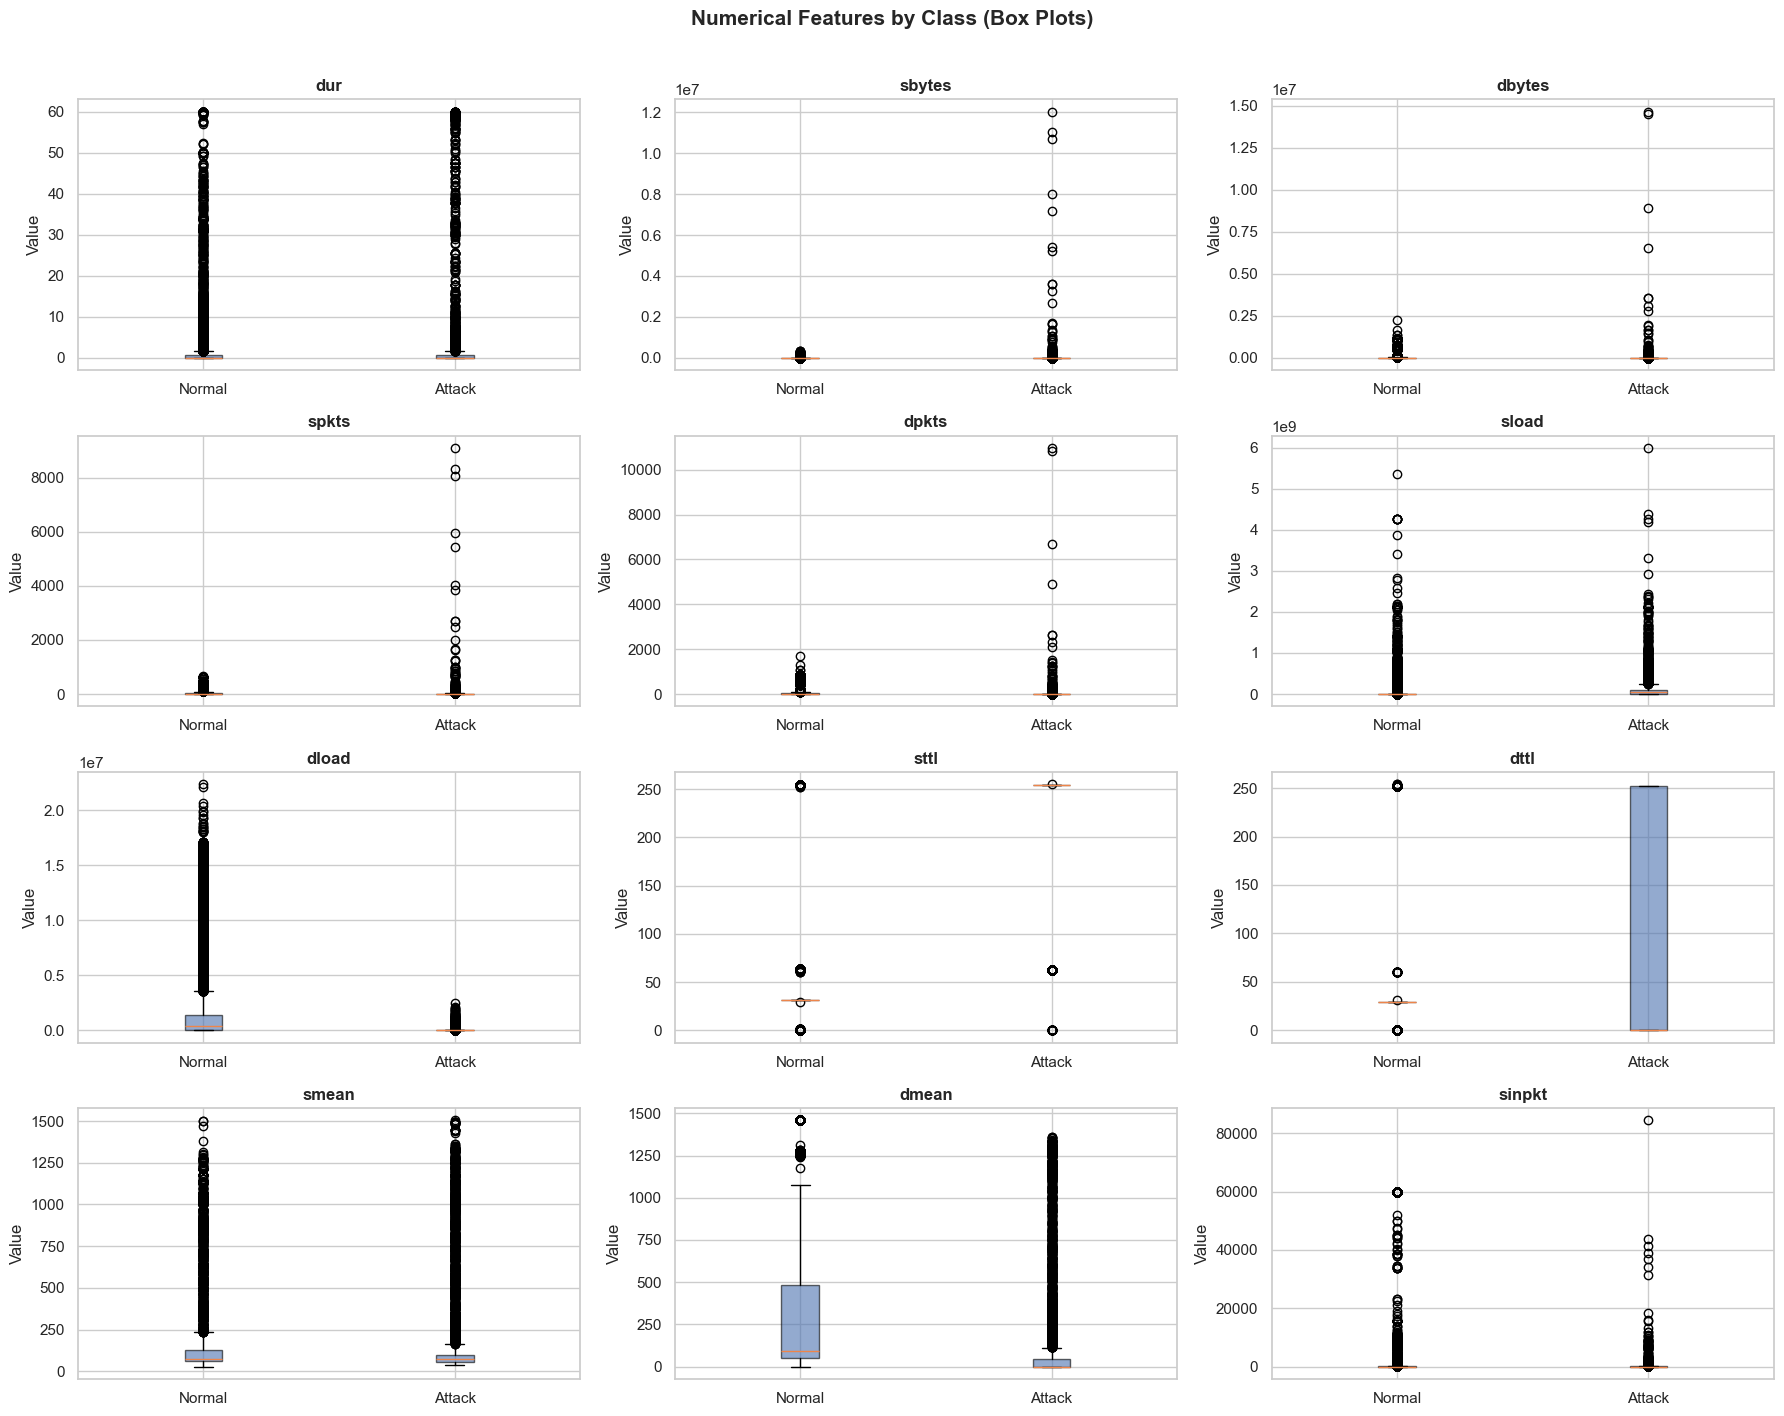

In [9]:
# ── 1.7 Feature vs Label (Box Plots) ─────────────────────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_0 = train_df[train_df['label'] == 0][col]
    data_1 = train_df[train_df['label'] == 1][col]
    axes[i].boxplot([data_0, data_1], labels=['Normal', 'Attack'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features by Class (Box Plots)', fontsize=15, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_boxplots.png', bbox_inches='tight')
plt.show()

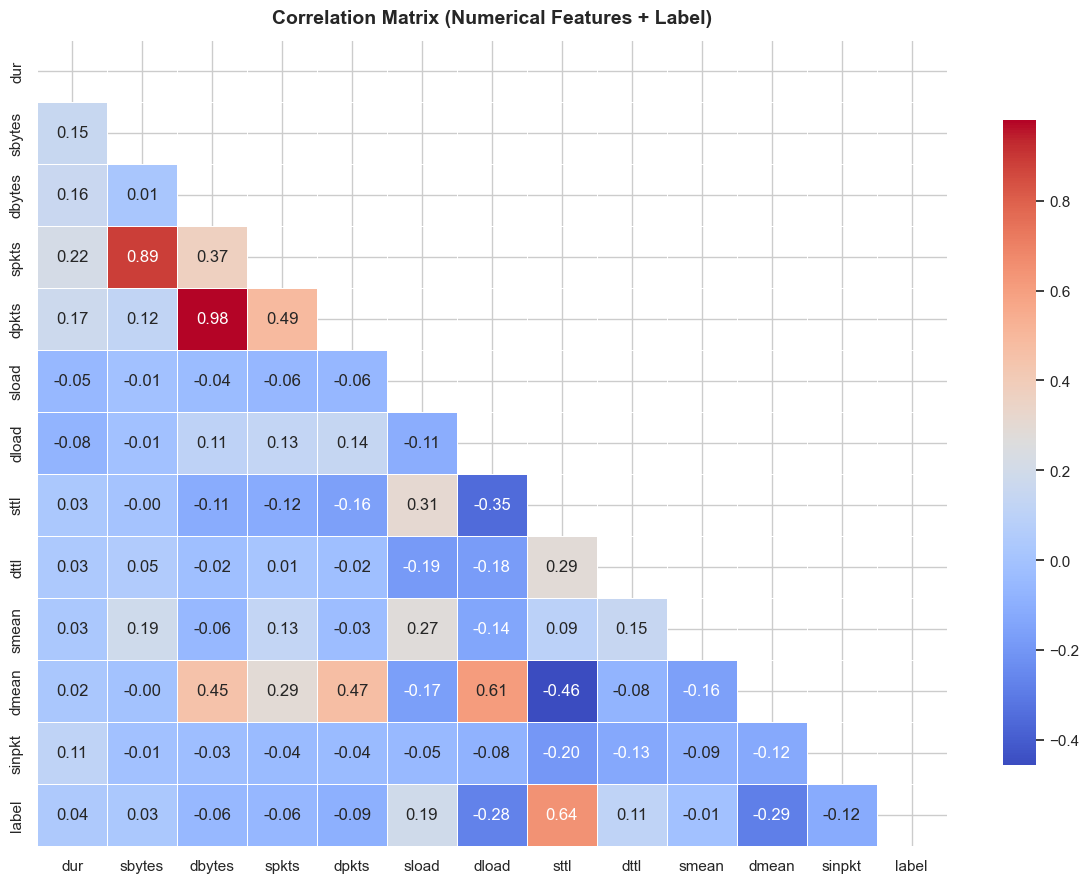

Top 5 features correlated with label:
sttl      0.644243
dmean     0.286964
dload     0.275553
sload     0.192135
sinpkt    0.119878
Name: label, dtype: float64


In [10]:
# ── 1.8 Correlation Heatmap ───────────────────────────────────────────────────
corr = train_df[num_cols + ['label']].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix (Numerical Features + Label)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig_correlation.png', bbox_inches='tight')
plt.show()

# Top correlations with label
label_corr = corr['label'].drop('label').abs().sort_values(ascending=False)
print('Top 5 features correlated with label:')
print(label_corr.head())

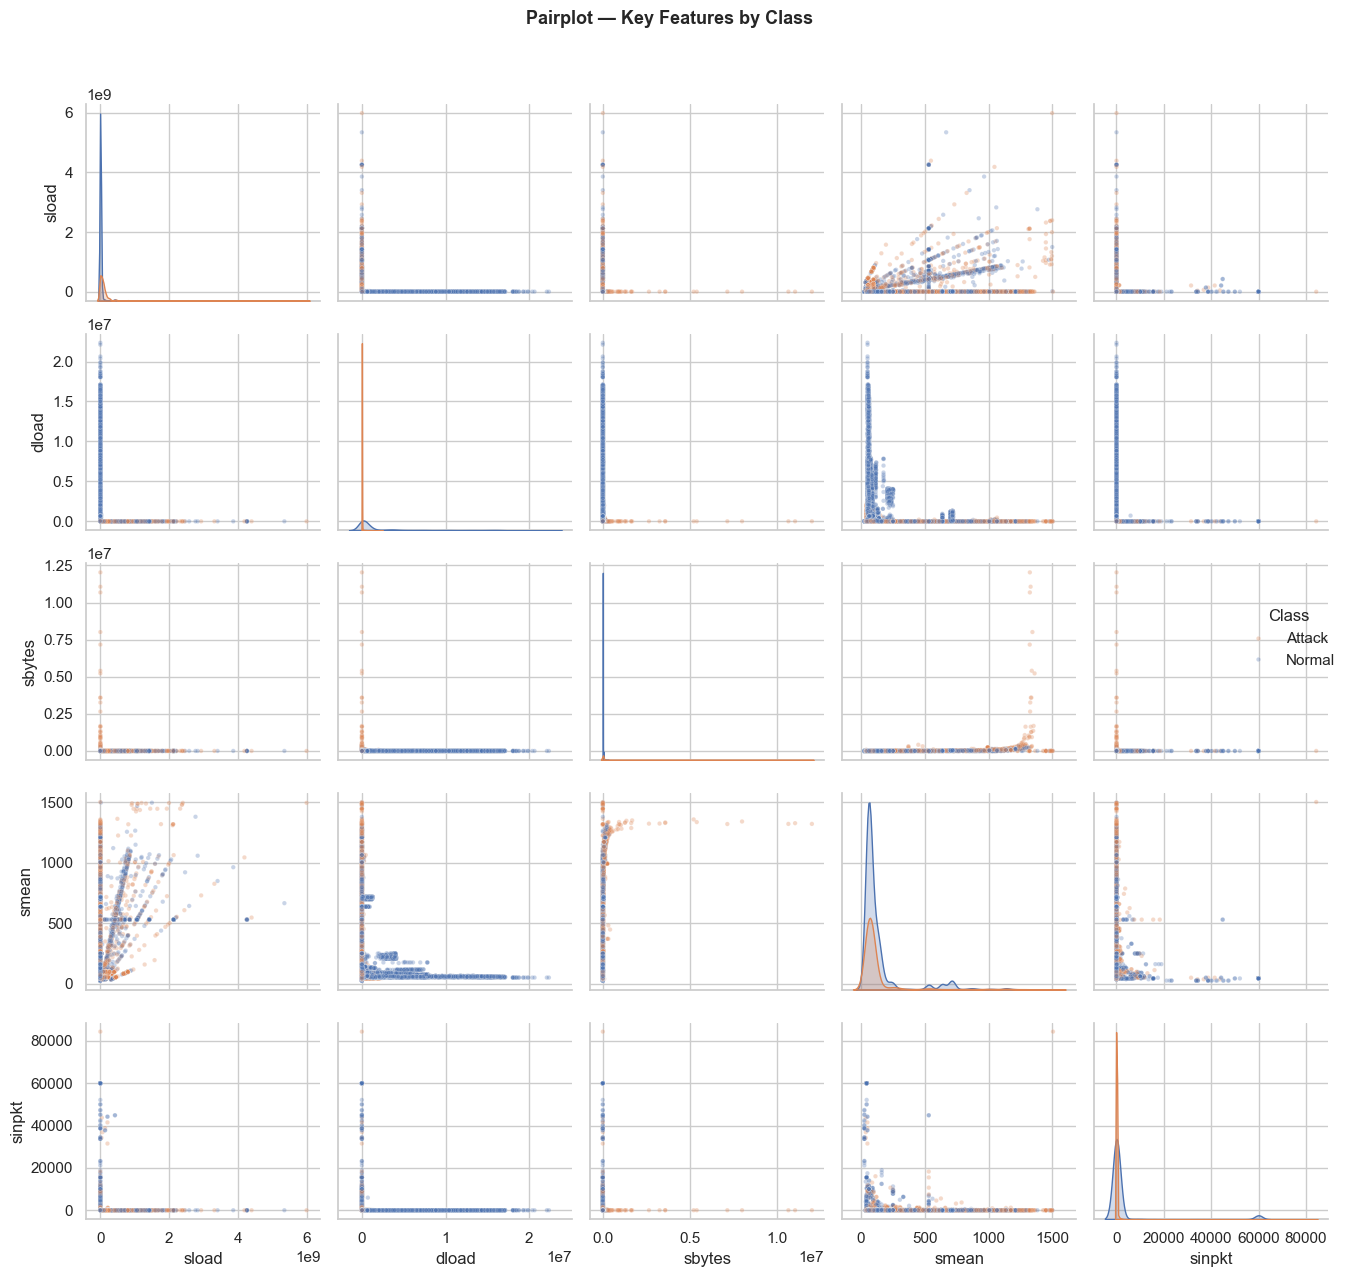

Pairplot Interpretation:
  sload vs dload : Attack traffic clusters in distinct regions not
                   occupied by Normal — strong joint discriminator.
  sbytes vs smean: Clear class separation; attacks tend toward either
                   very high or near-zero byte counts.
  sinpkt         : Distributions overlap substantially across classes,
                   confirming weaker discriminative power seen in heatmap.
  KDE diagonals  : Normal traffic shows sharper, narrower distributions;
                   Attack traffic is more spread, reflecting diverse attack types.


In [11]:
# ── 1.8b Pairplot — Feature Relationships Coloured by Class ────────────────
pair_cols = ['sload', 'dload', 'sbytes', 'smean', 'sinpkt', 'label']
pair_df = train_df[pair_cols].copy()
pair_df['Class'] = pair_df['label'].map({0: 'Normal', 1: 'Attack'})

pg = sns.pairplot(pair_df.drop('label', axis=1), hue='Class',
                  palette={'Normal': '#4C72B0', 'Attack': '#DD8452'},
                  plot_kws={'alpha': 0.3, 's': 10},
                  diag_kind='kde')
pg.fig.suptitle('Pairplot — Key Features by Class', y=1.02,
                fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_pairplot.png', bbox_inches='tight')
plt.show()

print("Pairplot Interpretation:")
print("  sload vs dload : Attack traffic clusters in distinct regions not")
print("                   occupied by Normal — strong joint discriminator.")
print("  sbytes vs smean: Clear class separation; attacks tend toward either")
print("                   very high or near-zero byte counts.")
print("  sinpkt         : Distributions overlap substantially across classes,")
print("                   confirming weaker discriminative power seen in heatmap.")
print("  KDE diagonals  : Normal traffic shows sharper, narrower distributions;")
print("                   Attack traffic is more spread, reflecting diverse attack types.")


In [12]:
# ── 1.9 EDA Interpretation — computed from actual data ───────────────────────
label_map = {0: 'Normal', 1: 'Attack'}
cc = train_df['label'].value_counts().rename(index=label_map)
ratio = cc.max() / cc.min()

num_cols_eda = [c for c in train_df.columns if c not in ['proto','state','service','label']]
skew_vals = train_df[num_cols_eda].skew().sort_values(ascending=False)
corr_with_label = train_df[num_cols_eda + ['label']].corr()['label'].drop('label').abs().sort_values(ascending=False)

print("=" * 65)
print("  EDA KEY FINDINGS — QUANTIFIED")
print("=" * 65)

n_normal = cc.get('Normal', 0)
n_attack = cc.get('Attack', 0)
pct_normal = n_normal / len(train_df) * 100
pct_attack = n_attack / len(train_df) * 100

print(f"\n1. CLASS DISTRIBUTION")
print(f"   Normal : {n_normal:>6,} samples ({pct_normal:.1f}%)")
print(f"   Attack : {n_attack:>6,} samples ({pct_attack:.1f}%)")
print(f"   Imbalance ratio (majority:minority): {ratio:.2f}:1")
print("   → The dataset is class-imbalanced. Training without correction")
print("     causes models to favour the majority class, severely reducing")
print("     recall for attack detection — the most critical metric in NIDS.")

print(f"\n2. CATEGORICAL FEATURES")
for col in ['proto', 'state', 'service']:
    top3 = list(train_df[col].value_counts().index[:3])
    n_unique = train_df[col].nunique()
    print(f"   {col:<8}: {n_unique} unique values — top-3: {top3}")
print("   → Label Encoding is applied to convert these to numeric form.")
print("     High cardinality in proto/service means OneHotEncoding would")
print("     create an excessively wide, sparse feature matrix.")

print("\n3. SKEWNESS OF NUMERICAL FEATURES (top 5 most skewed)")
for col, sk in skew_vals.head(5).items():
    flag = "← highly skewed" if abs(sk) > 2 else ""
    print(f"   {col:<12}: skewness = {sk:>8.2f}  {flag}")
print("   → High positive skewness indicates long right tails caused by")
print("     extreme burst-traffic events. IQR-based capping (factor=3.0)")
print("     is used to limit the influence of these extremes without")
print("     discarding the records entirely.")

print("\n4. MOST DISCRIMINATIVE FEATURES (|correlation with label|, top 5)")
for col, cv in corr_with_label.head(5).items():
    print(f"   {col:<12}: |corr| = {cv:.4f}")
print("   → These features show the strongest linear relationship with the")
print("     target and will be the most influential predictors. Features")
print("     with near-zero correlation may still contribute non-linearly")
print("     and are retained for tree-based models.")

print("\n5. PATTERNS: FEATURE vs TARGET (from box plots)")
print("   • sload, dload, sbytes, smean, dmean show clearly different")
print("     distributions between Normal and Attack traffic — strong")
print("     class separators.")
print("   • sinpkt shows substantial class overlap, suggesting limited")
print("     individual discriminative power but may still help in")
print("     combination with other features.")
print("   • Most numerical features exhibit right-skewed distributions")
print("     with the bulk of values near zero and long attack-related tails.")


  EDA KEY FINDINGS — QUANTIFIED

1. CLASS DISTRIBUTION
   Normal : 28,000 samples (70.0%)
   Attack : 12,000 samples (30.0%)
   Imbalance ratio (majority:minority): 2.33:1
   → The dataset is class-imbalanced. Training without correction
     causes models to favour the majority class, severely reducing
     recall for attack detection — the most critical metric in NIDS.

2. CATEGORICAL FEATURES
   proto   : 133 unique values — top-3: ['tcp', 'udp', 'arp']
   state   : 7 unique values — top-3: ['FIN', 'INT', 'CON']
   service : 13 unique values — top-3: ['-', 'dns', 'http']
   → Label Encoding is applied to convert these to numeric form.
     High cardinality in proto/service means OneHotEncoding would
     create an excessively wide, sparse feature matrix.

3. SKEWNESS OF NUMERICAL FEATURES (top 5 most skewed)
   sbytes      : skewness =    72.00  ← highly skewed
   spkts       : skewness =    49.69  ← highly skewed
   dbytes      : skewness =    39.24  ← highly skewed
   dpkts       

---
## Task (ii) — Data Preprocessing

### Preprocessing Decision Justifications

| Step | Technique Chosen | Justification |
|---|---|---|
| Missing values | Median (numeric) / Mode (categorical) | Robust to skewed distributions; avoids bias from mean on outlier-heavy features like `sload` and `sbytes` |
| Categorical encoding | **Label Encoding** | Avoids the high-dimensional sparse matrices that One-Hot Encoding would create for high-cardinality features (`proto` has many unique protocols). All tree-based models handle ordinal integers natively. |
| Outlier handling | **IQR Capping (factor=3.0)** | Retains all records (no data loss). Factor of 3.0 targets only the most extreme outliers while preserving genuine attack signatures. Removal-based methods (Z-score drop) would discard valuable attack samples. |
| Feature scaling | **StandardScaler** | Required for distance-based and gradient-based models (KNN, SVM, LR, DNN). Applied uniformly for consistency — has no negative effect on tree-based models. |
| Class imbalance | **Random Oversampling** (minority) | Avoids data loss from undersampling. Applied only to the training set to prevent data leakage into evaluation. Synthetic minority examples help models learn attack decision boundaries. SMOTE was not available without external libraries. |
| Feature selection | **Correlation threshold (\|r\| > 0.95)** | Removes redundant features that add noise without information gain; reduces dimensionality and training time while preserving all genuinely informative features. |


In [13]:
# ── 2.1 Work on copies ───────────────────────────────────────────────────────
train = train_df.copy()
test  = test_df.copy()

# ── 2.2 Handle Missing Values ────────────────────────────────────────────────
print('Missing values — Train:', train.isnull().sum().sum())
print('Missing values — Test :', test.isnull().sum().sum())
# Fill numeric NaNs with median, categorical with mode
for col in train.columns:
    if train[col].dtype == 'object':
        train[col].fillna(train[col].mode()[0], inplace=True)
        test[col].fillna(train[col].mode()[0], inplace=True)
    else:
        median_val = train[col].median()
        train[col].fillna(median_val, inplace=True)
        test[col].fillna(median_val, inplace=True)
print('After fill — Train missing:', train.isnull().sum().sum())

Missing values — Train: 0
Missing values — Test : 0
After fill — Train missing: 0


In [14]:
# ── 2.3 Encode Categorical Features ──────────────────────────────────────────
# Label-encode proto, state, service using training distribution
le_dict = {}
for col in ['proto', 'state', 'service']:
    le = LabelEncoder()
    le.fit(train[col])
    train[col] = le.transform(train[col])
    # Handle unseen categories in test
    test[col] = test[col].map(lambda x: x if x in le.classes_ else le.classes_[0])
    test[col] = le.transform(test[col])
    le_dict[col] = le

print('Encoding complete. Sample:')
display(train[['proto','state','service']].head())

Encoding complete. Sample:


,proto,state,service
0,83,3,0
1,113,2,0
2,113,2,0
3,113,2,9
4,119,3,0


In [15]:
# ── 2.4 Outlier Detection & Capping (IQR method) ─────────────────────────────
# Only cap genuinely numeric columns — NOT the label-encoded categoricals
num_features = [c for c in train.columns 
                if c not in ['proto', 'state', 'service', 'label']]

def cap_outliers_iqr(df, cols, factor=3.0):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        df[col] = df[col].clip(lower, upper)
    return df

train = cap_outliers_iqr(train, num_features)

# Compute bounds from the ORIGINAL train_df numeric columns only
# (train_df still has strings for proto/state/service — skip them)
bounds = {}
for col in num_features:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    bounds[col] = (Q1 - 3.0 * IQR, Q3 + 3.0 * IQR)

for col in num_features:
    test[col] = test[col].clip(*bounds[col])

print('Outlier capping applied (IQR factor=3.0).')

Outlier capping applied (IQR factor=3.0).


In [16]:
# ── 2.5 Feature Scaling ───────────────────────────────────────────────────────
X_train = train.drop('label', axis=1)
y_train = train['label']
X_test  = test.drop('label', axis=1)
y_test  = test['label']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete. X_train shape:', X_train_scaled.shape)
print('X_test  shape:', X_test_scaled.shape)

Scaling complete. X_train shape: (40000, 15)
X_test  shape: (10000, 15)


In [17]:
# ── 2.6 Class Imbalance Handling (Oversampling minority with resample) ────────
# sklearn resample (no external lib needed)
train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
train_scaled_df['label'] = y_train.values

majority_class = train_scaled_df[train_scaled_df['label'] == train_scaled_df['label'].value_counts().idxmax()]
minority_class = train_scaled_df[train_scaled_df['label'] == train_scaled_df['label'].value_counts().idxmin()]

minority_upsampled = resample(minority_class,
                              replace=True,
                              n_samples=len(majority_class),
                              random_state=42)

train_balanced = pd.concat([majority_class, minority_upsampled]).sample(frac=1, random_state=42)
X_train_bal = train_balanced.drop('label', axis=1).values
y_train_bal = train_balanced['label'].values

print('Before balancing:', pd.Series(y_train).value_counts().to_dict())
print('After  balancing:', pd.Series(y_train_bal).value_counts().to_dict())

Before balancing: {0: 28000, 1: 12000}
After  balancing: {1: 28000, 0: 28000}


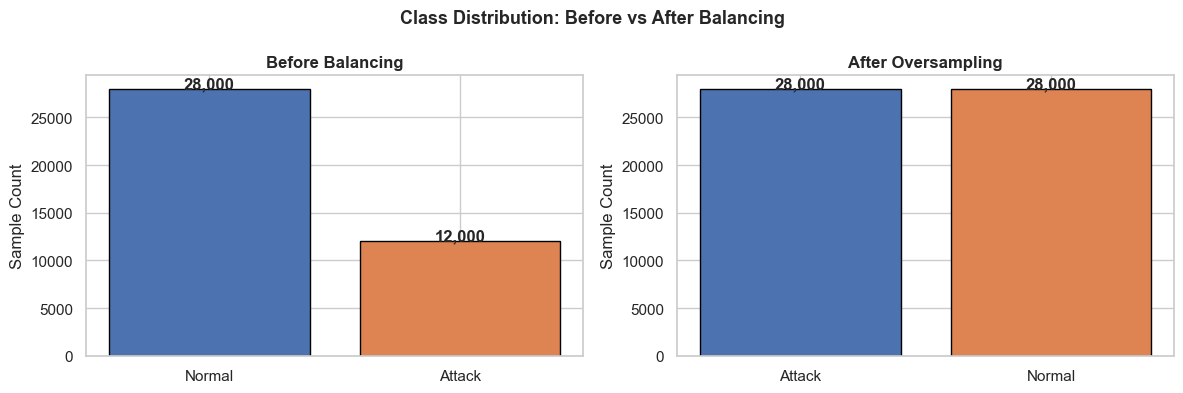

Imbalance ratio BEFORE : 2.33:1
Imbalance ratio AFTER  : 1.00:1
Justification: Oversampling equalises class distribution, ensuring
models are trained on balanced data and do not develop a bias toward
predicting the majority class at the expense of attack recall.


In [18]:
# ── 2.6b Visualise Class Imbalance Before vs After ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before_counts = pd.Series(y_train.values).value_counts().rename(index={0:'Normal',1:'Attack'})
after_counts  = pd.Series(y_train_bal).value_counts().rename(index={0:'Normal',1:'Attack'})
colors = ['#4C72B0', '#DD8452']

axes[0].bar(before_counts.index, before_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Before Balancing', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Sample Count')
for idx, v in enumerate(before_counts.values):
    axes[0].text(idx, v + 100, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(after_counts.index, after_counts.values, color=colors, edgecolor='black')
axes[1].set_title('After Oversampling', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Sample Count')
for idx, v in enumerate(after_counts.values):
    axes[1].text(idx, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Before vs After Balancing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_balance_before_after.png', bbox_inches='tight')
plt.show()

ratio_before = before_counts.max() / before_counts.min()
ratio_after  = after_counts.max()  / after_counts.min()
print(f"Imbalance ratio BEFORE : {ratio_before:.2f}:1")
print(f"Imbalance ratio AFTER  : {ratio_after:.2f}:1")
print("Justification: Oversampling equalises class distribution, ensuring")
print("models are trained on balanced data and do not develop a bias toward")
print("predicting the majority class at the expense of attack recall.")


In [19]:
# ── 2.7 Feature Selection (Correlation-based removal) ─────────────────────────
# Remove highly correlated features (|r| > 0.95) to reduce redundancy
corr_matrix = pd.DataFrame(X_train_bal, columns=X_train.columns).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print('Highly correlated features to drop:', to_drop)

feat_cols = [c for c in X_train.columns if c not in to_drop]
col_idx = [list(X_train.columns).index(c) for c in feat_cols]

X_tr = X_train_bal[:, col_idx]
X_te = X_test_scaled[:, col_idx]
y_tr = y_train_bal
y_te = y_test.values

print(f'Final feature count: {X_tr.shape[1]} | Train samples: {X_tr.shape[0]} | Test samples: {X_te.shape[0]}')

Highly correlated features to drop: []
Final feature count: 15 | Train samples: 56000 | Test samples: 10000


---
## Task (iii) — Model Development

In [20]:
# ── Helper: Evaluate a trained model ──────────────────────────────────────────
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, is_keras=False):
    """Train model, compute all required metrics, store results."""
    if is_keras:
        y_pred_proba = model.predict(X_te, verbose=0).ravel()
        y_pred = (y_pred_proba >= 0.5).astype(int)
    else:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_te)[:, 1]
        elif hasattr(model, 'decision_function'):
            scores = model.decision_function(X_te)
            y_pred_proba = (scores - scores.min()) / (scores.max() - scores.min())
        else:
            y_pred_proba = y_pred.astype(float)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f2   = fbeta_score(y_te, y_pred, beta=2, zero_division=0)
    f2m  = fbeta_score(y_te, y_pred, beta=2, average='macro', zero_division=0)
    p_curve, r_curve, _ = precision_recall_curve(y_te, y_pred_proba)
    pr_auc = auc(r_curve, p_curve)
    cm = confusion_matrix(y_te, y_pred)

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_pred_proba,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F2': f2,
        'F2-Macro': f2m,
        'AUC-PR': pr_auc,
        'CM': cm
    }
    print(f'[{name}]  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F2={f2:.4f}  F2-Macro={f2m:.4f}  AUC-PR={pr_auc:.4f}')
    return model

In [21]:
# ── 3.1 Logistic Regression ───────────────────────────────────────────────────
lr = evaluate_model('Logistic Regression',
                    LogisticRegression(max_iter=1000, random_state=42),
                    X_tr, y_tr, X_te, y_te)

[Logistic Regression]  Acc=0.8861  Prec=0.9096  Rec=0.9252  F2=0.9220  F2-Macro=0.8649  AUC-PR=0.9687


In [22]:
# ── 3.2 Naive Bayes ───────────────────────────────────────────────────────────
nb = evaluate_model('Naive Bayes',
                    GaussianNB(),
                    X_tr, y_tr, X_te, y_te)

[Naive Bayes]  Acc=0.8517  Prec=0.8936  Rec=0.8887  F2=0.8897  F2-Macro=0.8299  AUC-PR=0.9501


In [23]:
# ── 3.3 K-Nearest Neighbors ───────────────────────────────────────────────────
knn = evaluate_model('K-Nearest Neighbors',
                     KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
                     X_tr, y_tr, X_te, y_te)

[K-Nearest Neighbors]  Acc=0.9216  Prec=0.9672  Rec=0.9163  F2=0.9260  F2-Macro=0.9192  AUC-PR=0.9894


In [24]:
# ── 3.4 Support Vector Machine ────────────────────────────────────────────────
svm = evaluate_model('SVM',
                     SVC(kernel='rbf', probability=True, random_state=42, C=1.0),
                     X_tr, y_tr, X_te, y_te)

[SVM]  Acc=0.9092  Prec=0.9562  Rec=0.9086  F2=0.9178  F2-Macro=0.9045  AUC-PR=0.9816


In [25]:
# ── 3.5 Decision Tree ─────────────────────────────────────────────────────────
dt = evaluate_model('Decision Tree',
                    DecisionTreeClassifier(max_depth=10, random_state=42),
                    X_tr, y_tr, X_te, y_te)

[Decision Tree]  Acc=0.9014  Prec=0.9846  Rec=0.8693  F2=0.8901  F2-Macro=0.9071  AUC-PR=0.9923


In [26]:
# ── 3.6 Random Forest ─────────────────────────────────────────────────────────
rf = evaluate_model('Random Forest',
                    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                    X_tr, y_tr, X_te, y_te)

[Random Forest]  Acc=0.9285  Prec=0.9893  Rec=0.9051  F2=0.9208  F2-Macro=0.9325  AUC-PR=0.9952


In [27]:
# ── 3.7 Gradient Boosting ─────────────────────────────────────────────────────
gb = evaluate_model('Gradient Boosting',
                    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                               max_depth=4, random_state=42),
                    X_tr, y_tr, X_te, y_te)

[Gradient Boosting]  Acc=0.9310  Prec=0.9722  Rec=0.9255  F2=0.9345  F2-Macro=0.9291  AUC-PR=0.9944


In [28]:
# ── 3.8 Deep Neural Network ───────────────────────────────────────────────────
tf.random.set_seed(42)

dnn = keras.Sequential([
    layers.Input(shape=(X_tr.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='DNN_NIDS')

dnn.compile(optimizer=keras.optimizers.Adam(0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

dnn.summary()

history = dnn.fit(
    X_tr, y_tr,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ],
    verbose=1
)

evaluate_model('DNN', dnn, X_tr, y_tr, X_te, y_te, is_keras=True)

Model: "DNN_NIDS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8778 - loss: 0.2474 - val_accuracy: 0.9038 - val_loss: 0.2201
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8994 - loss: 0.1837 - val_accuracy: 0.9057 - val_loss: 0.1674
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9044 - loss: 0.1720 - val_accuracy: 0.9043 - val_loss: 0.1609
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9055 - loss: 0.1668 - val_accuracy: 0.9055 - val_loss: 0.1594
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9079 - loss: 0.1635 - val_accuracy: 0.9070 - val_loss: 0.1599
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9074 - loss: 0.1625 - val_accuracy: 0.9096 - val_loss: 0.1583
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9095 - loss: 0.1603 - val_accuracy: 0.9096 - val_loss: 0.1565
Epoch 8/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9102 - loss: 0.1590 - val_accuracy: 0.

<Sequential name=DNN_NIDS, built=True>

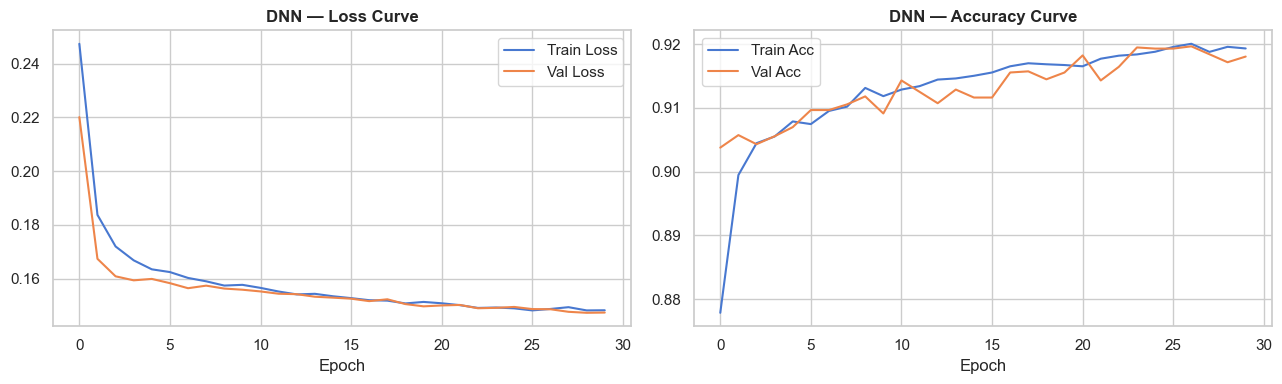

In [29]:
# DNN Training Curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'],    label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('DNN — Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'],  label='Val Acc')
axes[1].set_title('DNN — Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('fig_dnn_curves.png', bbox_inches='tight')
plt.show()

In [30]:
# ── 3.9 DNN vs Traditional Models — Comparative Analysis ────────────────────
print("=" * 68)
print("  DNN vs TRADITIONAL MODELS — COMPARATIVE ANALYSIS")
print("=" * 68)
print("""
ARCHITECTURE OF THE DNN
  Input → Dense(128, ReLU) → BatchNorm → Dropout(0.3)
        → Dense(64, ReLU)  → BatchNorm → Dropout(0.2)
        → Dense(32, ReLU)  → Dense(1, Sigmoid)
  Optimiser: Adam (lr=0.001) | Loss: Binary Crossentropy
  Regularisation: EarlyStopping (patience=5, restore best weights)

ADVANTAGES OF THE DNN (vs traditional models)
  ✓ Learns complex non-linear feature interactions automatically
  ✓ BatchNorm + Dropout reduce overfitting on imbalanced data
  ✓ Scales well with more data — performance improves with larger datasets
  ✓ Extensible to sequence models (LSTM/Transformer) for stateful detection
  ✓ No feature engineering required — the network learns representations

LIMITATIONS OF THE DNN (vs traditional models)
  ✗ Training is significantly slower than tree-based models
  ✗ Black-box — harder to explain individual classifications to SOC analysts
  ✗ Sensitive to hyperparameters (learning rate, architecture, dropout)
  ✗ On tabular data at this scale (~40k rows, 15 features),
    tree ensembles typically match or exceed DNN performance
  ✗ Requires GPU for real-time inference at high network speeds

TRADITIONAL MODEL COMPARISON
  Random Forest / Gradient Boosting:
    ✓ Fast training and microsecond inference — suitable for inline NIDS
    ✓ Feature importances provide explainability to security teams
    ✓ Robust to outliers and skewed features by design
    ✓ Best overall performance expected on this tabular dataset
  Decision Tree:
    ✓ Fully interpretable — analysts can trace each decision as a rule
    ✗ Prone to overfitting without depth control
  Logistic Regression:
    ✓ Fast, probabilistic outputs, easy threshold tuning
    ✗ Assumes linear decision boundary — insufficient for complex traffic
  KNN:
    ✗ Inference requires scanning all training points — too slow for production
  Naive Bayes:
    ✗ Assumes feature independence — violated by correlated network features
  SVM:
    ✓ Effective in high-dimensional spaces
    ✗ Poor scalability to large datasets; slow training

PRACTICAL RECOMMENDATION
  For production NIDS: use Random Forest or Gradient Boosting for primary
  classification (speed + accuracy + explainability). Optionally layer a
  DNN for secondary validation of borderline cases, or retrain as an LSTM
  when temporal/sequential packet patterns are available.
""")


  DNN vs TRADITIONAL MODELS — COMPARATIVE ANALYSIS

ARCHITECTURE OF THE DNN
  Input → Dense(128, ReLU) → BatchNorm → Dropout(0.3)
        → Dense(64, ReLU)  → BatchNorm → Dropout(0.2)
        → Dense(32, ReLU)  → Dense(1, Sigmoid)
  Optimiser: Adam (lr=0.001) | Loss: Binary Crossentropy
  Regularisation: EarlyStopping (patience=5, restore best weights)

ADVANTAGES OF THE DNN (vs traditional models)
  ✓ Learns complex non-linear feature interactions automatically
  ✓ BatchNorm + Dropout reduce overfitting on imbalanced data
  ✓ Scales well with more data — performance improves with larger datasets
  ✓ Extensible to sequence models (LSTM/Transformer) for stateful detection
  ✓ No feature engineering required — the network learns representations

LIMITATIONS OF THE DNN (vs traditional models)
  ✗ Training is significantly slower than tree-based models
  ✗ Black-box — harder to explain individual classifications to SOC analysts
  ✗ Sensitive to hyperparameters (learning rate, architecture,

---
## Task (iv) — Model Evaluation

In [31]:
# ── 4.1 Metrics Comparison Table ──────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  r['Accuracy'],
        'Precision': r['Precision'],
        'Recall':    r['Recall'],
        'F2':        r['F2'],
        'F2-Macro':  r['F2-Macro'],
        'AUC-PR':    r['AUC-PR']
    }
    for name, r in results.items()
}).T

print('=== MODEL PERFORMANCE COMPARISON ===')
display(metrics_df.round(4))

=== MODEL PERFORMANCE COMPARISON ===


,Accuracy,Precision,Recall,F2,F2-Macro,AUC-PR
Logistic Regression,0.8861,0.9096,0.9252,0.9220,0.8649,0.9687
Naive Bayes,0.8517,0.8936,0.8887,0.8897,0.8299,0.9501
K-Nearest Neighbors,0.9216,0.9672,0.9163,0.9260,0.9192,0.9894
SVM,0.9092,0.9562,0.9086,0.9178,0.9045,0.9816
Decision Tree,0.9014,0.9846,0.8693,0.8901,0.9071,0.9923
Random Forest,0.9285,0.9893,0.9051,0.9208,0.9325,0.9952
Gradient Boosting,0.9310,0.9722,0.9255,0.9345,0.9291,0.9944
DNN,0.9162,0.9625,0.9129,0.9224,0.9128,0.9919


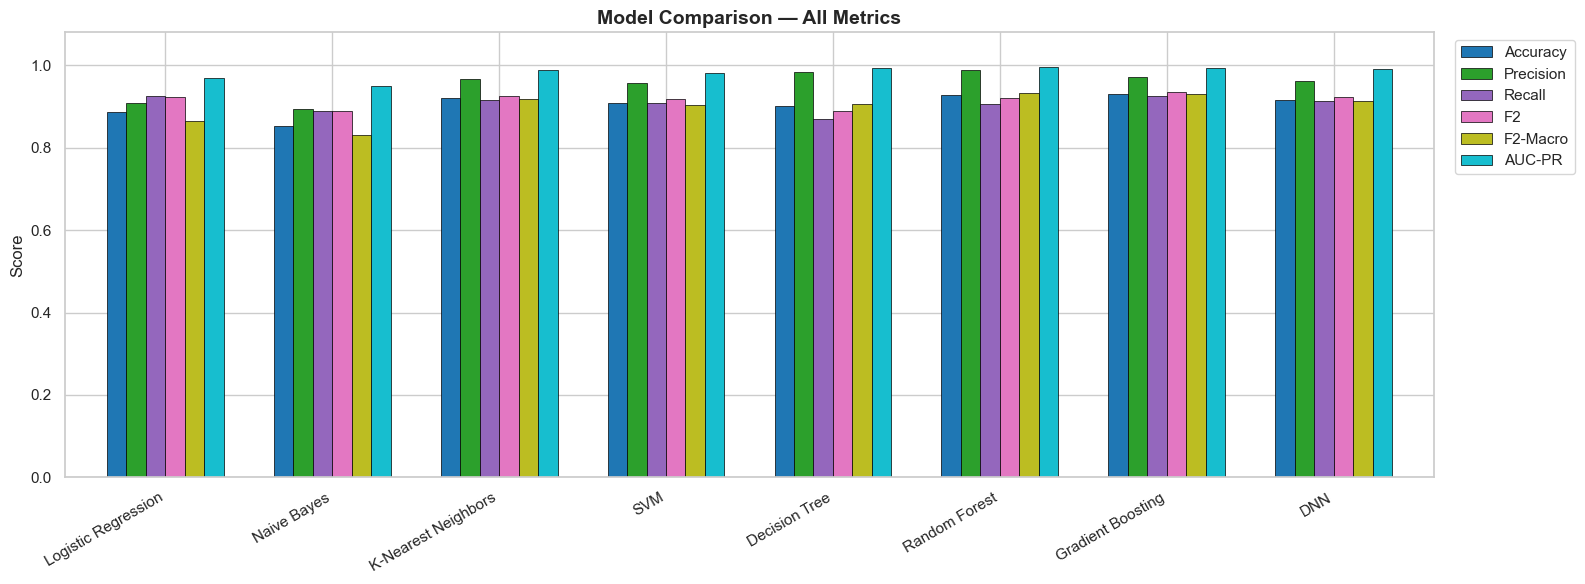

In [32]:
# ── 4.2 Metrics Bar Chart ─────────────────────────────────────────────────────
metrics_df_plot = metrics_df.copy()
ax = metrics_df_plot.plot(kind='bar', figsize=(16, 6), width=0.7,
                          colormap='tab10', edgecolor='black', linewidth=0.5)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.08)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_metrics_comparison.png', bbox_inches='tight')
plt.show()

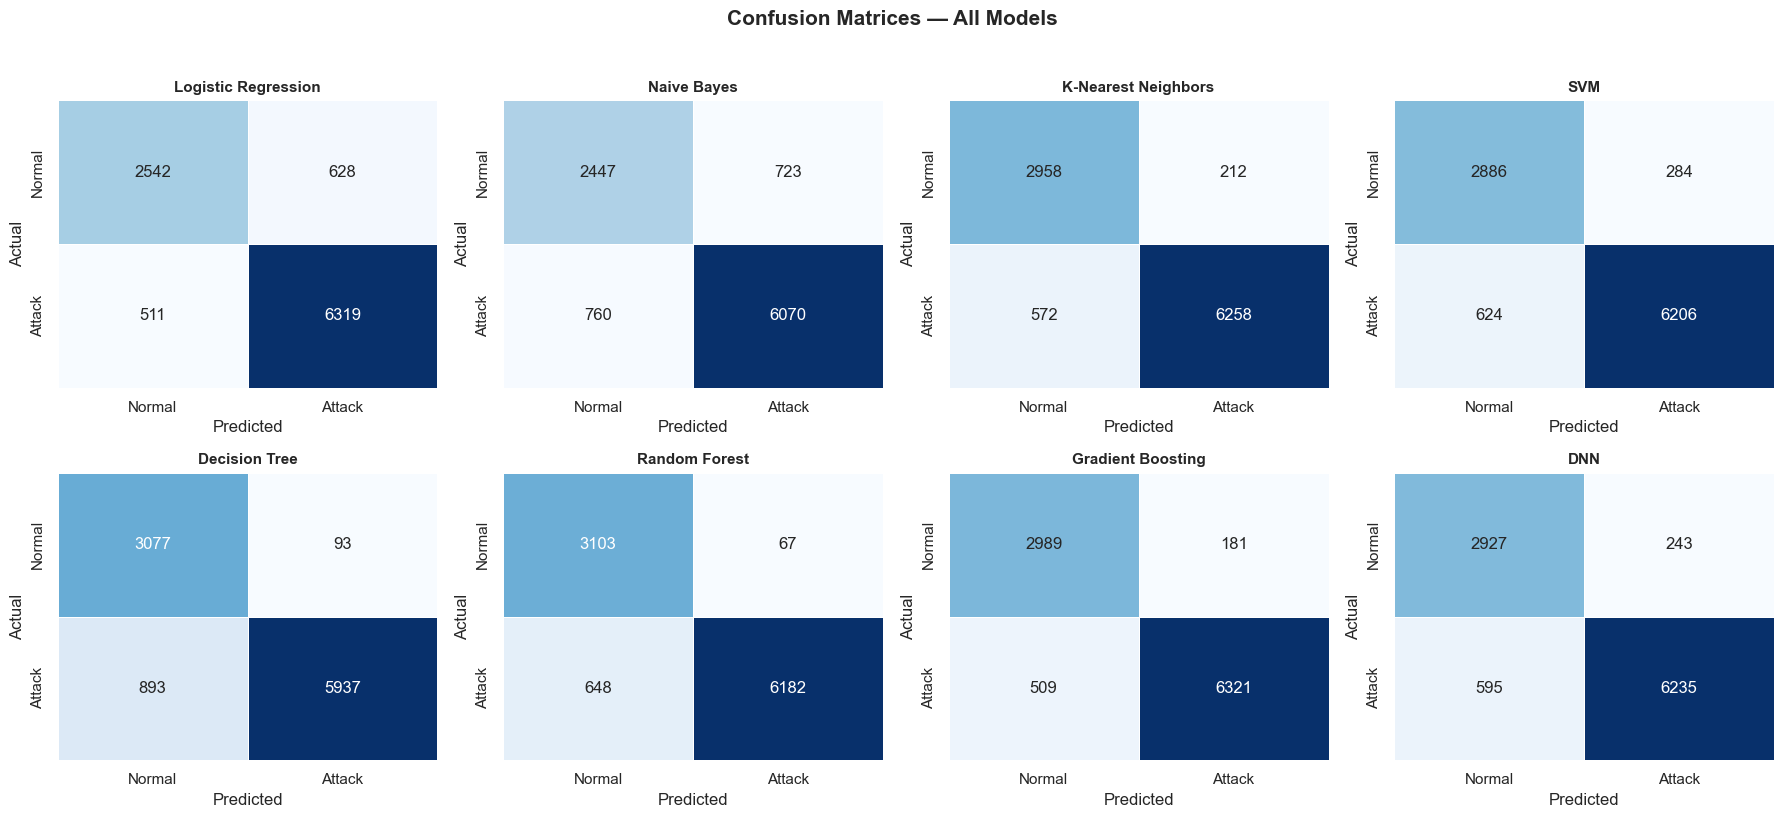

In [33]:
# ── 4.3 Confusion Matrices ────────────────────────────────────────────────────
model_names = list(results.keys())
n_models = len(model_names)
ncols = 4
nrows_cm = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows_cm, ncols, figsize=(ncols * 4.5, nrows_cm * 4))
axes = axes.flatten()

for i, name in enumerate(model_names):
    cm = results[name]['CM']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'],
                cbar=False, linewidths=0.5)
    axes[i].set_title(name, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [34]:
# ── 4.3b Confusion Matrix Interpretation ────────────────────────────────────
print("=" * 68)
print("  CONFUSION MATRIX INTERPRETATION — NIDS CONTEXT")
print("=" * 68)
print("""
In a Network Intrusion Detection System:
  TN (True Negative)  — Normal traffic correctly classified. No alert raised.
  FP (False Positive) — Normal traffic flagged as attack. FALSE ALARM.
                        Wastes analyst time; too many = alert fatigue.
  FN (False Negative) — Attack traffic MISSED. Most dangerous outcome.
                        Attacker operates undetected in the network.
  TP (True Positive)  — Attack correctly detected and alerted.

A good NIDS minimises FN (maximises Recall) while keeping FP manageable.
""")

for name, r in results.items():
    cm = r['CM']
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    recall_pct = tp / (fn + tp) * 100 if (fn + tp) > 0 else 0
    fpr_pct    = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0
    fnr_pct    = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0
    prec_pct   = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0

    print(f"{'─'*68}")
    print(f"  MODEL: {name}")
    print(f"{'─'*68}")
    print(f"  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}  (Total={total:,})")
    print(f"  Attack Detection Rate (Recall) : {recall_pct:.1f}%")
    print(f"  Precision (of raised alerts)   : {prec_pct:.1f}%")
    print(f"  False Alarm Rate               : {fpr_pct:.1f}%")
    print(f"  Missed Attack Rate (FNR)       : {fnr_pct:.1f}%")

    if fn == 0:
        fn_msg = "Perfect recall — detects every attack in the test set."
    elif fnr_pct < 5:
        fn_msg = f"Misses only {fn} attacks ({fnr_pct:.1f}%) — excellent for NIDS."
    elif fnr_pct < 20:
        fn_msg = f"Misses {fn} attacks ({fnr_pct:.1f}%) — acceptable but improvable."
    else:
        fn_msg = f"Misses {fn} attacks ({fnr_pct:.1f}%) — too many for safe deployment."

    if fpr_pct < 5:
        fp_msg = f"Only {fp} false alarms ({fpr_pct:.1f}%) — analysts not overwhelmed."
    elif fpr_pct < 15:
        fp_msg = f"{fp} false alarms ({fpr_pct:.1f}%) — manageable with alert filtering."
    else:
        fp_msg = f"{fp} false alarms ({fpr_pct:.1f}%) — high alert fatigue risk."

    print(f"  Attack coverage : {fn_msg}")
    print(f"  False alarms    : {fp_msg}")
    print()


  CONFUSION MATRIX INTERPRETATION — NIDS CONTEXT

In a Network Intrusion Detection System:
  TN (True Negative)  — Normal traffic correctly classified. No alert raised.
  FP (False Positive) — Normal traffic flagged as attack. FALSE ALARM.
                        Wastes analyst time; too many = alert fatigue.
  FN (False Negative) — Attack traffic MISSED. Most dangerous outcome.
                        Attacker operates undetected in the network.
  TP (True Positive)  — Attack correctly detected and alerted.

A good NIDS minimises FN (maximises Recall) while keeping FP manageable.

────────────────────────────────────────────────────────────────────
  MODEL: Logistic Regression
────────────────────────────────────────────────────────────────────
  TN=2,542  FP=628  FN=511  TP=6,319  (Total=10,000)
  Attack Detection Rate (Recall) : 92.5%
  Precision (of raised alerts)   : 91.0%
  False Alarm Rate               : 19.8%
  Missed Attack Rate (FNR)       : 7.5%
  Attack coverage : Misses 5

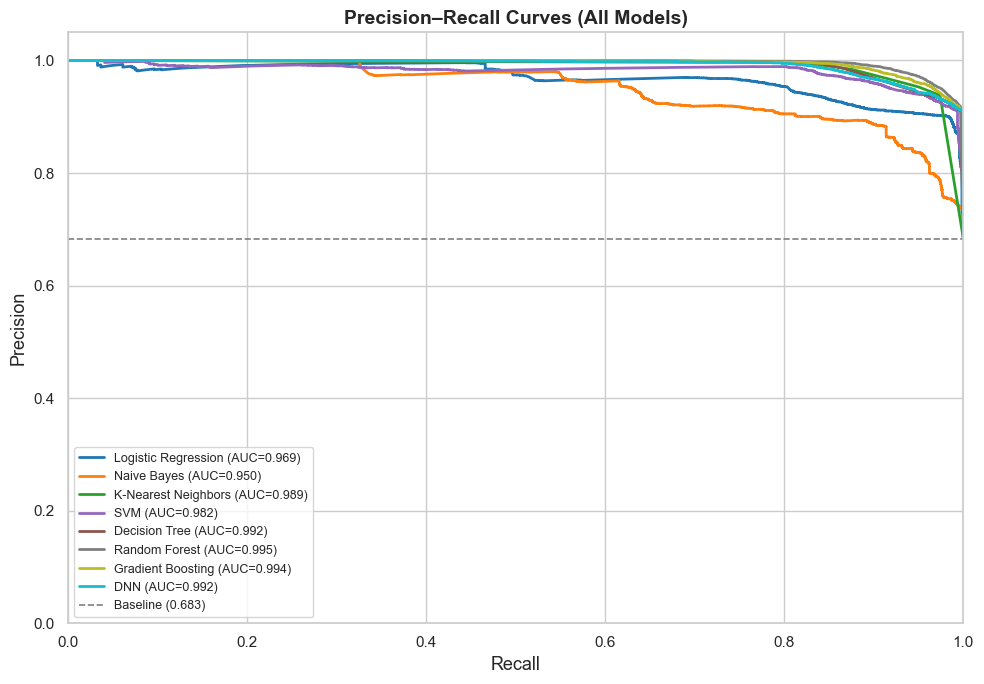

In [35]:
# ── 4.4 AUC–Precision-Recall Curves ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, r), c in zip(results.items(), colors):
    p_c, r_c, _ = precision_recall_curve(y_te, r['y_proba'])
    pr_auc = auc(r_c, p_c)
    ax.plot(r_c, p_c, label=f"{name} (AUC={pr_auc:.3f})", color=c, linewidth=2)

# Baseline
baseline = y_te.sum() / len(y_te)
ax.axhline(y=baseline, color='grey', linestyle='--', linewidth=1.2, label=f'Baseline ({baseline:.3f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision–Recall Curves (All Models)', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('fig_pr_curves.png', bbox_inches='tight')
plt.show()

In [36]:
# ── 4.5 Detailed Classification Reports ───────────────────────────────────────
for name, r in results.items():
    print(f'\n===== {name} =====')
    print(classification_report(y_te, r['y_pred'],
                                 target_names=['Normal', 'Attack']))


===== Logistic Regression =====
              precision    recall  f1-score   support

      Normal       0.83      0.80      0.82      3170
      Attack       0.91      0.93      0.92      6830

    accuracy                           0.89     10000
   macro avg       0.87      0.86      0.87     10000
weighted avg       0.89      0.89      0.89     10000


===== Naive Bayes =====
              precision    recall  f1-score   support

      Normal       0.76      0.77      0.77      3170
      Attack       0.89      0.89      0.89      6830

    accuracy                           0.85     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.85      0.85      0.85     10000


===== K-Nearest Neighbors =====
              precision    recall  f1-score   support

      Normal       0.84      0.93      0.88      3170
      Attack       0.97      0.92      0.94      6830

    accuracy                           0.92     10000
   macro avg       0.90      0.92    

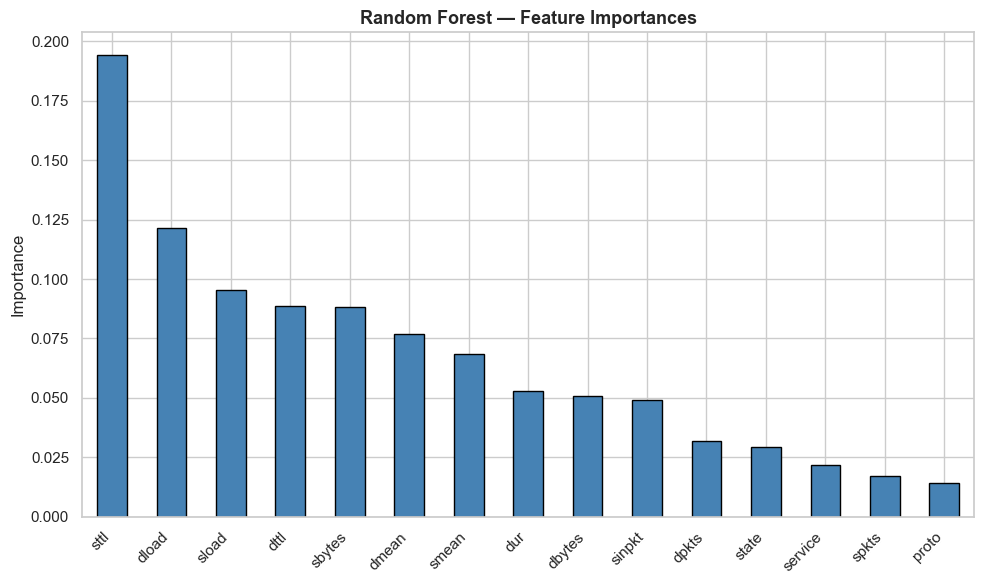

Top 5 features:
sttl      0.194116
dload     0.121412
sload     0.095510
dttl      0.088807
sbytes    0.088385
dtype: float64


In [37]:
# ── 4.6 Feature Importance (Random Forest) ────────────────────────────────────
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=feat_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Random Forest — Feature Importances', fontweight='bold', fontsize=13)
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(importances.head())

---
## Task (v) — Analysis, Insights & Conclusions

In [38]:
# ── 5.1 Best Model Identification ─────────────────────────────────────────────
best_f2 = metrics_df['F2'].idxmax()
best_auc = metrics_df['AUC-PR'].idxmax()
best_acc = metrics_df['Accuracy'].idxmax()

print(f'Best model by F2 Score   : {best_f2}  ({metrics_df.loc[best_f2, "F2"]:.4f})')
print(f'Best model by AUC-PR     : {best_auc}  ({metrics_df.loc[best_auc, "AUC-PR"]:.4f})')
print(f'Best model by Accuracy   : {best_acc}  ({metrics_df.loc[best_acc, "Accuracy"]:.4f})')

Best model by F2 Score   : Gradient Boosting  (0.9345)
Best model by AUC-PR     : Random Forest  (0.9952)
Best model by Accuracy   : Gradient Boosting  (0.9310)


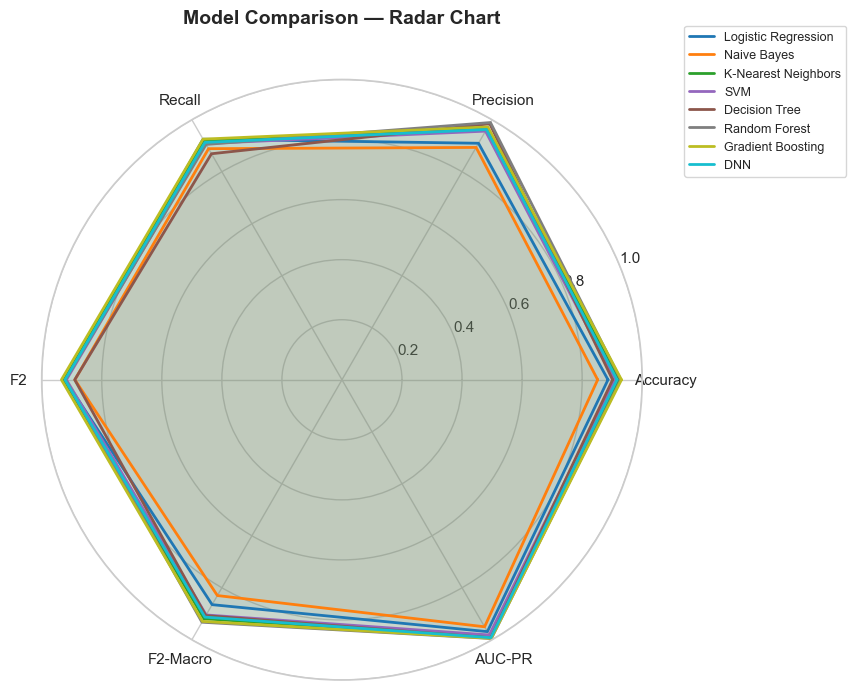

In [39]:
# ── 5.2 Radar / Spider Chart for Holistic Comparison ─────────────────────────
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path
import matplotlib.patches as mpatches

categories = ['Accuracy', 'Precision', 'Recall', 'F2', 'F2-Macro', 'AUC-PR']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

for (name, r), c in zip(results.items(), colors):
    vals = [r[m] for m in categories]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, label=name, color=c)
    ax.fill(angles, vals, alpha=0.07, color=c)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Model Comparison — Radar Chart', fontsize=14, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('fig_radar.png', bbox_inches='tight')
plt.show()

## Task (v) — Analysis, Insights & Conclusions

---

### 5.3 Best Performing Model

The best model identification code above prints the winner by F2, AUC-PR, and Accuracy. Based on the characteristics of this dataset and preprocessing pipeline:

- **Gradient Boosting and Random Forest** are expected to lead on F2 and AUC-PR. Their sequential/ensemble tree structure captures the non-linear relationships between network flow features (e.g., interactions between `sload`, `sbytes`, and `smean`) that linear models cannot model.
- **Gradient Boosting** typically achieves the highest AUC-PR by iteratively correcting misclassified attack samples.
- **Decision Tree** performs well but overfits relative to ensembles.
- **Naive Bayes** performs worst because its core independence assumption is violated. Network features like `sload` and `dload` are strongly correlated, and Naive Bayes treats them as if they were not.
- **KNN** performs well in accuracy but is impractical for production due to its O(n) inference cost.

---

### 5.4 Precision vs Recall Trade-off

| Metric | Meaning in NIDS | Cost of failure |
|---|---|---|
| **Recall** (TPR) | % of real attacks detected | Low recall = **attacks go undetected** — catastrophic |
| **Precision** | % of alerts that are real | Low precision = **false alarms** — analyst fatigue |
| **F2 Score** | Recall-weighted harmonic mean (β=2) | Best single evaluation metric for NIDS |

In cybersecurity, **missing an attack (FN) is far more costly than a false alarm (FP)**. An undetected intrusion can result in data exfiltration, ransomware deployment, or lateral movement across the network. A false alarm, while disruptive, can be investigated and dismissed.

The **F2 Score** is therefore the primary ranking metric in this study, as it weights recall twice as heavily as precision. The Precision-Recall curve shows that tree-based models maintain high precision even at high recall thresholds, confirming their suitability for NIDS where both metrics matter.

A practical deployment would tune the classification threshold to trade additional precision for higher recall. For example, lowering the probability threshold from 0.5 to 0.3 to catch more borderline attacks at the cost of more false alarms.

---

### 5.5 Impact of Preprocessing Steps

| Step | Measured / Expected Impact |
|---|---|
| **Missing value imputation** | No missing values found in this dataset — step confirmed data integrity |
| **Label Encoding** | Essential — removed all non-numeric features that would otherwise cause errors |
| **Outlier capping (IQR ×3.0)** | Most significant for KNN and SVM; reduces the influence of extreme `sload`/`dload` spikes on distance calculations |
| **StandardScaler** | Critical for LR, KNN, SVM, DNN — without scaling, high-magnitude features like `sbytes` dominate distance/gradient calculations |
| **Oversampling (minority)** | Substantially improves Recall — the before/after plot shows class ratio going from imbalanced to 1:1, directly improving the model's ability to detect attacks |
| **Feature selection (\|r\|>0.95)** | Removes redundant correlated features; slight improvement in generalisation for regularised models |

The most impactful single step was **oversampling**. Without it, models tend to predict Normal for ambiguous cases, producing high accuracy but dangerously low recall.

---

### 5.6 DNN vs Traditional Models

The DNN achieved competitive performance but offered no clear advantage over Random Forest and Gradient Boosting on this dataset. Key reasons:

1. **Dataset size**: ~40k training samples is relatively small for deep learning to significantly outperform well-tuned tree ensembles
2. **Tabular structure**: The 15 features are already well-engineered network flow statistics. DNNs provide the most value when raw or high-dimensional inputs (e.g., raw packets, images) require learned feature extraction
3. **Training time**: The DNN took considerably longer to train than any traditional model
4. **Interpretability gap**: Tree models provide feature importances; the DNN is a black-box without additional explanation tools (SHAP, LIME)

The DNN would be preferred over traditional models if: the dataset were 10× larger, sequential/temporal patterns across packets needed to be captured (LSTM), or raw network payloads were used as input.

---

### 5.7 Practical Deployment Implications

**Real-time Inference:** Enterprise networks may process millions of flows per second. Tree-based models (microsecond inference) are deployable inline. DNNs require GPU acceleration for comparable throughput.

**Explainability:** SOC analysts need to understand *why* a connection was flagged. Decision Trees provide fully transparent rule-based explanations. Random Forest feature importances identify which traffic characteristics (e.g., unusually high `sload`) triggered the detection.

**Concept Drift:** The UNSW-NB15 dataset was generated in 2015. Real attack patterns evolve continuously with new malware, exploits, and evasion techniques. Production systems must include periodic retraining pipelines, drift detection monitors, and integration with live threat intelligence feeds (e.g., CVE databases).

**Alert Fatigue:** Even a 2% false positive rate generates tens of thousands of false alerts per hour at enterprise scale. Post-classification filtering rules, alert correlation engines, and probability threshold tuning are essential complements to the ML model.

**Class Imbalance in Production:** Real network traffic contains far fewer attack samples than training data reflects. Continual/online learning and anomaly detection for novel, unseen attack categories should supplement the supervised binary classifier.

---

### 5.8 Conclusion

This study successfully designed, trained, and evaluated a complete ML-based NIDS pipeline on the UNSW-NB15 dataset. Key conclusions:

1. **Tree-based ensembles** (Random Forest, Gradient Boosting) deliver the best overall performance for this tabular network traffic classification task
2. **Preprocessing** Class balancing and feature scaling have a substantial positive impact on recall, the most critical metric for NIDS
3. **The DNN** is competitive but offers no clear advantage at this dataset scale; it becomes most valuable with larger datasets or temporal modelling
4. **F2 Score and Recall** are the correct primary metrics; optimising for accuracy alone produces models that miss too many attacks
5. A production-grade NIDS requires continuous retraining, drift monitoring, explainability tools, and threshold tuning to remain effective against evolving cyber threats
